# 9.1 Which locations should we label next?

**Question:** With a budget of 50 labels, is it better to sample randomly or ask the model where it is uncertain?

**Objectives:** implement a pool-based active-learning loop; keep unqueried labels hidden from selection; compare acquisition strategies under an equal budget; assess geographic coverage and model failure.

**Prerequisites:** lesson 7.1 or basic classification and DataFrames. **Time:** 90–120 minutes. **Setup:** base course dependencies only; no GPU, accounts or downloads.

**Data:** synthetic sites, predictors and binary labels. Local kilometre coordinates are invented. No ecological, hazard or field-sampling claims follow from the results. All labels exist in our simulation, but acquisition functions receive labels only after requesting a site. This models annotation cost; it is not a security boundary.

## The learning loop

`initial labeled sites - fit - score unlabeled candidates - choose a batch - request labels - refit`

**Random sampling** explores without relying on the current model. **Uncertainty sampling** requests the highest predictive entropy: `-sum(p * log(p))`. For two classes it peaks at probabilities 0.5/0.5. This is predictive uncertainty, not necessarily reducible uncertainty: noisy examples can remain uncertain forever, and an incorrect model can be confidently wrong.

Use the same 10 initial sites per paired run, five new labels per round, and **50 total labels including the initial 10**. Model settings and budgets are fixed before scoring. Label cost is assumed equal; real travel time and annotation difficulty can differ.

The classifier is a small random forest—an ensemble of decision trees. See [scikit-learn RandomForestClassifier](https://scikit-learn.org/stable/modules/generated/sklearn.ensemble.RandomForestClassifier.html).

In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import balanced_accuracy_score
from IPython.display import display

ROOT = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / 'course.py').exists())
OUT = ROOT/'data'/'generated'/'active_learning'
OUT.mkdir(parents=True, exist_ok=True)
rng = np.random.default_rng(42)
n = 1400
sites = pd.DataFrame({'site_id': np.arange(n), 'x_km': rng.uniform(0, 100, n), 'y_km': rng.uniform(0, 100, n)})
sites['ndvi'] = rng.uniform(0, 1, n)
sites['moisture'] = rng.uniform(0, 1, n)
sites['elevation_m'] = 500 + 20 * sites.y_km + rng.normal(0, 30, n)
# The northern region follows a different invented response threshold.
north = (sites.y_km >= 70).to_numpy()
latent = sites.ndvi.to_numpy() + 0.6 * sites.moisture.to_numpy()
all_labels = (latent > np.where(north, 1.15, 0.75)).astype(int)
flip = rng.random(n) < 0.04
all_labels[flip] = 1 - all_labels[flip]
FEATURES = ['ndvi', 'moisture', 'elevation_m']
pool_ids = sites.index[sites.x_km < 70].to_numpy()
test_ids = sites.index[sites.x_km >= 80].to_numpy()
# The 70–80 km strip is unused; it provides a simple separation buffer.
pool = sites.loc[pool_ids].copy()
X_pool = pool[FEATURES].to_numpy()
assert set(pool_ids).isdisjoint(test_ids)
assert sites.loc[pool_ids, 'x_km'].max() < sites.loc[test_ids, 'x_km'].min() - 10
assert set(all_labels[test_ids]) == {0, 1}
print('Candidate sites:', len(pool_ids), '| fixed eastern test sites:', len(test_ids))
print('No test labels will be available to the acquisition loop.')

Candidate sites: 979 | fixed eastern test sites: 283
No test labels will be available to the acquisition loop.


## A budgeted annotation oracle

The “oracle” stands in for a person obtaining a field label. It rejects test IDs, duplicate requests and requests beyond the 50-label budget. Its labels are kept in a closure; the loop only receives requested labels. The full synthetic truth is used later by a separate evaluator.

Both strategies begin with sites from the southern region (y < 50), selected using coordinates only. This intentionally creates weak northern coverage. Do not search through hidden labels to ensure a favorable starting class mix. A one-class start is permitted; entropy will then be zero and randomized tie-breaking provides exploration.

In [2]:
TOTAL_BUDGET, INITIAL_LABELS, BATCH = 50, 10, 5

def make_oracle(allowed_ids, truth, budget):
    lookup = {int(i): int(truth[i]) for i in allowed_ids}
    queried = set()
    def request(ids):
        ids = [int(i) for i in ids]
        if len(ids) != len(set(ids)) or any(i in queried for i in ids):
            raise ValueError('A label may be acquired only once.')
        if any(i not in lookup for i in ids):
            raise ValueError('Only acquisition-pool sites can be labeled.')
        if len(queried) + len(ids) > budget:
            raise ValueError('Label budget exceeded.')
        queried.update(ids)
        return np.array([lookup[i] for i in ids])
    return request

def entropy(probabilities):
    return -(probabilities * np.log(np.clip(probabilities, 1e-12, 1))).sum(axis=1)

assert entropy(np.array([[0.5, 0.5]]))[0] > entropy(np.array([[0.99, 0.01]]))[0]
# Audit the oracle on disposable state; this does not spend the experiment's budget.
audit = make_oracle(pool_ids, all_labels, 1)
audit([pool_ids[0]])
for invalid in [[pool_ids[0]], [pool_ids[1]], [test_ids[0]]]:
    try: audit(invalid)
    except ValueError: pass
    else: raise AssertionError('Oracle accepted an invalid request.')
print('Entropy and oracle rejection checks passed.')

Entropy and oracle rejection checks passed.


## Select without seeing unqueried labels

Each run receives only pool features, IDs, initial indices and its annotation callback. It never receives test features or test labels. We save model snapshots and acquisition logs, then evaluate them **after every acquisition run has finished**. The test curve is for reporting, never early stopping, model selection or changing the next request.

Batch uncertainty sampling can choose redundant nearby examples because all five points are selected before retraining. This lesson does not add a diversity penalty. Random tie-breaking avoids silently favoring low-index sites.

In [3]:
def run_acquisition(features, ids, initial_positions, request_labels, strategy, seed):
    if strategy not in ['random', 'uncertainty']:
        raise ValueError('Unknown strategy')
    random = np.random.default_rng(seed)
    chosen = list(map(int, initial_positions))
    known_labels = list(request_labels(ids[chosen]))
    log = [{'site_id': int(ids[pos]), 'round': 0, 'selection_entropy': np.nan} for pos in chosen]
    snapshots = []
    while True:
        model = RandomForestClassifier(n_estimators=40, max_depth=5, min_samples_leaf=2,
                                       random_state=seed, n_jobs=1)
        model.fit(features[chosen], known_labels)
        snapshots.append({'budget': len(chosen), 'model': model, 'selected_ids': ids[chosen].copy()})
        if len(chosen) == TOTAL_BUDGET: break
        available = np.setdiff1d(np.arange(len(ids)), chosen)
        candidates = random.permutation(available)
        uncertainty = entropy(model.predict_proba(features[candidates]))
        ranking = np.arange(len(candidates)) if strategy == 'random' else np.argsort(-uncertainty, kind='stable')
        number = min(BATCH, TOTAL_BUDGET - len(chosen))
        take = ranking[:number]
        new_positions = candidates[take]
        # No labels were consulted before these positions were chosen.
        new_labels = request_labels(ids[new_positions])
        round_number = (len(chosen) - INITIAL_LABELS) // BATCH + 1
        log.extend({'site_id': int(ids[pos]), 'round': round_number, 'selection_entropy': float(score)}
                   for pos, score in zip(new_positions, uncertainty[take]))
        chosen.extend(new_positions.tolist()); known_labels.extend(new_labels.tolist())
    assert len(chosen) == TOTAL_BUDGET and len(set(chosen)) == TOTAL_BUDGET
    return snapshots, pd.DataFrame(log)

SEEDS = [3, 11, 19, 27, 35]  # Fixed before scoring; paired starts within each seed.
runs = {}
eligible = np.flatnonzero(pool.y_km.to_numpy() < 50)
for seed in SEEDS:
    initial = np.random.default_rng(seed).choice(eligible, INITIAL_LABELS, replace=False)
    for strategy in ['random', 'uncertainty']:
        oracle = make_oracle(pool_ids, all_labels, TOTAL_BUDGET)
        runs[(seed, strategy)] = run_acquisition(X_pool, pool_ids, initial, oracle, strategy, seed)
    a, b = [runs[(seed, strategy)][0][0]['selected_ids'] for strategy in ['random', 'uncertainty']]
    assert np.array_equal(a, b)
print('Finished all acquisition runs before any test scoring.')

Finished all acquisition runs before any test scoring.


## Report learning curves on fixed geography

All runs use the same eastern test sites and fixed budgets: 10, 15, …, 50. Balanced accuracy averages class recall. The shaded range shows **minimum to maximum across five sampling seeds**, not a confidence interval. These runs share one dataset and one test region; they do not quantify uncertainty across landscapes.

Sampling uncertainty is not a performance guarantee. Uncertainty sampling can lose to random sampling, especially when its initial model overlooks an unfamiliar region.

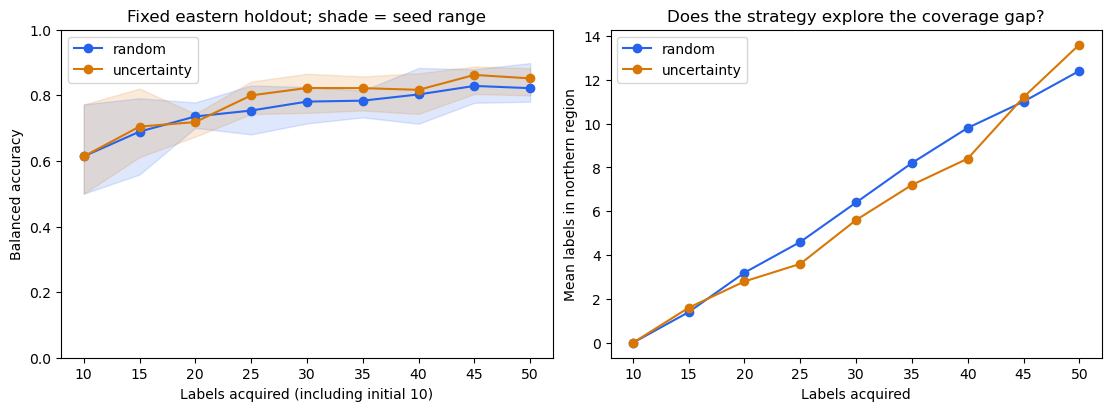

strategy,random,uncertainty
seed,,
3,0.780539,0.870579
11,0.849619,0.882470
19,0.782063,0.799898
27,0.798069,0.862170
35,0.898120,0.842175


In [4]:
evaluation = []
X_test, y_test = sites.loc[test_ids, FEATURES].to_numpy(), all_labels[test_ids]
for (seed, strategy), (snapshots, log) in runs.items():
    for snapshot in snapshots:
        selected_ids = snapshot['selected_ids']
        assert not set(selected_ids) & set(test_ids)
        evaluation.append({'seed': seed, 'strategy': strategy, 'labels': snapshot['budget'],
                           'balanced_accuracy': balanced_accuracy_score(y_test, snapshot['model'].predict(X_test)),
                           'northern_labels': int(north[selected_ids].sum())})
results = pd.DataFrame(evaluation)
assert set(results.labels) == set(range(10, 51, 5))
assert results.balanced_accuracy.between(0, 1).all()
summary = results.groupby(['strategy', 'labels']).balanced_accuracy.agg(['mean', 'min', 'max']).reset_index()
fig, axes = plt.subplots(1, 2, figsize=(11, 4), constrained_layout=True)
for strategy, color in [('random', '#2563eb'), ('uncertainty', '#d97706')]:
    subset = summary[summary.strategy == strategy]
    axes[0].plot(subset.labels, subset['mean'], marker='o', label=strategy, color=color)
    axes[0].fill_between(subset.labels, subset['min'], subset['max'], color=color, alpha=0.15)
    coverage = results[results.strategy == strategy].groupby('labels').northern_labels.mean()
    axes[1].plot(coverage.index, coverage.values, marker='o', label=strategy, color=color)
axes[0].set(xlabel='Labels acquired (including initial 10)', ylabel='Balanced accuracy', ylim=(0, 1),
            title='Fixed eastern holdout; shade = seed range')
axes[1].set(xlabel='Labels acquired', ylabel='Mean labels in northern region', title='Does the strategy explore the coverage gap?')
for ax in axes: ax.legend()
fig.savefig(OUT/'learning_curves.png', dpi=140); plt.show()
display(results[results.labels == 50].pivot(index='seed', columns='strategy', values='balanced_accuracy'))
results.to_csv(OUT/'learning_curves.csv', index=False)

## Map the selected locations

Use the first predeclared seed for illustration, not whichever run looks best. Circles show acquisitions; stars show the common initial sites. Colors indicate acquisition round, not class. The northern shaded region is missing from the initial set, and the eastern test region is never eligible for acquisition.

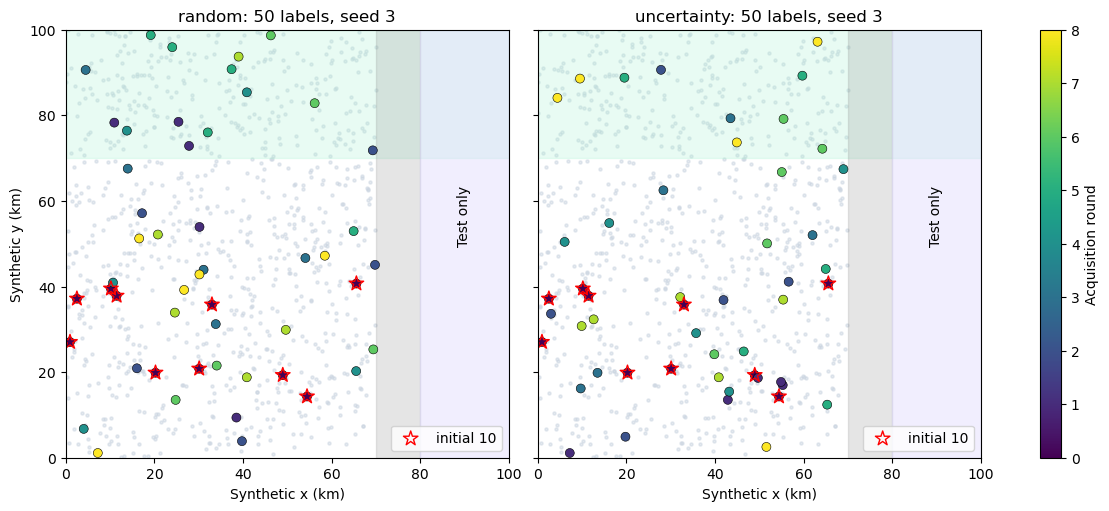

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(11, 5), sharex=True, sharey=True, constrained_layout=True)
for ax, strategy in zip(axes, ['random', 'uncertainty']):
    snapshots, log = runs[(SEEDS[0], strategy)]
    selected = sites.loc[log.site_id].copy()
    ax.scatter(pool.x_km, pool.y_km, color='#cbd5e1', s=5, alpha=0.5)
    ax.axhspan(70, 100, color='#a7f3d0', alpha=0.25)
    ax.axvspan(70, 80, color='gray', alpha=0.2)
    ax.axvspan(80, 100, color='#ddd6fe', alpha=0.4)
    im = ax.scatter(selected.x_km, selected.y_km, c=log['round'], cmap='viridis', vmin=0, vmax=8,
                    s=42, edgecolors='black', linewidths=0.4)
    initial = selected.iloc[:INITIAL_LABELS]
    ax.scatter(initial.x_km, initial.y_km, marker='*', s=120, facecolors='none', edgecolors='red', label='initial 10')
    ax.text(90, 50, 'Test only', rotation=90, ha='center')
    ax.set(title=f'{strategy}: 50 labels, seed {SEEDS[0]}', xlabel='Synthetic x (km)', xlim=(0, 100), ylim=(0, 100))
    ax.legend(loc='lower right')
axes[0].set_ylabel('Synthetic y (km)')
fig.colorbar(im, ax=axes, label='Acquisition round')
fig.savefig(OUT/'selection_maps.png', dpi=140); plt.show()

logs = []
for (seed, strategy), (_, log) in runs.items():
    logs.append(log.assign(seed=seed, strategy=strategy))
pd.concat(logs, ignore_index=True).to_csv(OUT/'acquisition_log.csv', index=False)

## Audit confidently wrong predictions

After acquisition is finished, use the simulator's hidden truth to inspect the initial model in the candidate pool. This is an **oracle audit**, unavailable to an actual selector before labeling. It must not influence the acquisition runs above.

Count unqueried candidate predictions with at least 0.9 confidence that are wrong. A nonzero count shows a limitation of uncertainty-only sampling. A zero count in one run would not establish calibrated confidence. Inspect northern coverage as well as aggregate test performance.

In [6]:
initial_snapshot = runs[(SEEDS[0], 'uncertainty')][0][0]
unqueried_ids = np.setdiff1d(pool_ids, initial_snapshot['selected_ids'])
audit_model = initial_snapshot['model']
audit_features = sites.loc[unqueried_ids, FEATURES].to_numpy()
confidence = audit_model.predict_proba(audit_features).max(axis=1)
wrong = audit_model.predict(audit_features) != all_labels[unqueried_ids]
audit_table = pd.DataFrame({'site_id': unqueried_ids, 'north': north[unqueried_ids],
                            'confidence': confidence, 'wrong': wrong})
display(audit_table.groupby('north').agg(candidates=('site_id', 'size'), mistakes=('wrong', 'sum'),
                                        mean_confidence=('confidence', 'mean')))
print('Confidently wrong unqueried candidates:', int(((confidence >= 0.9) & wrong).sum()))
print('This audit uses hidden synthetic labels only AFTER the selection experiment.')

,candidates,mistakes,mean_confidence
north,,,
False,668,344,0.770340
True,301,42,0.752712


Confidently wrong unqueried candidates: 9
This audit uses hidden synthetic labels only AFTER the selection experiment.


## Your independent challenge

1. Predict whether a mixed batch (two random + three uncertain sites) will improve northern coverage. Implement it without duplicate queries and keep the total budget at 50.
2. Repeat with initial sites drawn from y < 30 rather than y < 50. Use the same starts for each strategy within each seed. Compare coverage and explain why uncertainty can miss an unfamiliar region.
3. Propose a development/validation region for choosing the mixed strategy. The eastern test curves have now been observed: do not tune repeatedly on them and call the result held out.
4. Recommend a sampling strategy in 100–150 words using acquisition cost, coverage, variability across seeds and error patterns. Do not assume active learning must win.

**Submit:** a budget/duplicate audit, a learning curve, a selection map and a recommendation. If computing new final-performance scores after development, reserve a new geographic test region first.

In [7]:
# Your controlled experiment here. Do not pass hidden labels or test results into the selector.

<details><summary>Solution guidance - open after trying</summary>

Choose two random candidates, remove them, then choose the three highest-entropy remaining candidates using the same pre-batch model. Request all five labels together and refit. Exclude previously queried IDs and random choices from the uncertainty step. A mixed strategy guarantees some exploration but does not guarantee better accuracy. Starting farther south can worsen geographic coverage; the measured effect depends on seed and model. Select a policy with separate development data, then freeze it before scoring a new geographic holdout. If costs vary, compare performance per total cost rather than per label alone.

</details>

## Check yourself and rubric

Why can the most uncertain locations be redundant? Why are confident predictions not proof of correctness? Which information may the selector see? What does a five-seed range leave unmeasured?

| Criterion | Points | Evidence |
|---|---:|---|
| Label and budget integrity | 3 | Hidden-label discipline, no duplicates, 50-label total |
| Fair evaluation | 3 | Paired starts, fixed model settings, geographic holdout isolated from selection |
| Independent experiment | 2 | Controlled change and coverage comparison |
| Decision communication | 2 | Evidence-based recommendation and real-cost limitations |

**Mastery target:** 8/10 with no test feedback or unqueried truth used for acquisition.

## Transfer to real data collection

Define a candidate sampling frame and what one label means. Record annotation uncertainty, access restrictions, travel time and permissions. Keep an independent geographic evaluation sample; do not train on it or request its labels through the acquisition loop. Consider geographic/feature diversity, class imbalance and an explicit exploration component. A model can be uncertain because of irreducible ambiguity, and uncertainty estimates may be miscalibrated outside the initial training region. Audit who and what the sampling plan excludes.

This is pool-based active learning, not semi-supervised learning: unqueried candidate features guide selection but their true labels are unavailable to training. In real deployment there is no complete hidden-truth audit; use independent field validation and carefully designed sampling.

## Educator note

Suggested 100 minutes: 15 for budget decisions and entropy, 20 for the oracle/loop, 20 for paired runs and curves, 15 for maps/confident errors, and 30 for the independent recommendation. For a Director demonstration, begin with “we can afford 50 labels—where should we spend them?” and finish with a learner's justified sampling plan rather than a model ranking.